In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

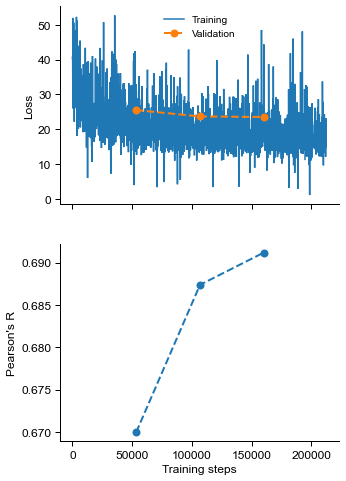

In [83]:
metrics = pd.read_csv(
 "models/regression_data_JUL10.batch1_v4_poisson_test/logs/lightning_logs/version_0/metrics.csv"
)
i = metrics.loss.abs() > 500
metrics.loc[i, "loss"] = pd.NA

val_steps = ~metrics.val_loss.isna()
val_metrics = metrics[val_steps]
train_metrics = metrics[~val_steps]


fig, ax = plt.subplots(2, 1, sharex=True)
ax[0].plot(train_metrics.step, train_metrics.loss, label="Training")
ax[0].plot(val_metrics.step, val_metrics.val_loss, "o--", lw=2, ms=8, label="Validation")
ax[0].set_ylabel("Loss")
ax[0].legend()

ax[1].plot(val_metrics.step, val_metrics.val_pcc, "o--", lw=2, ms=8, label="Validation")
ax[1].set_xlabel("Training steps")
ax[1].set_ylabel("Pearson's R")

fig.set_size_inches(5, 8)

In [84]:
val_metrics

,epoch,loss,step,val_loss,val_pcc
533,0,NaN,53381,25.473284,0.669955
1068,0,NaN,106763,23.647221,0.687373
1603,0,NaN,160145,23.487593,0.691186
